# Walmart Sales Analysis: what actually drives store sales?

**Analyst:** Nishad Rashid Mahi
**Tools:** Python (pandas, matplotlib), SQL (SQLite), Tableau, Excel

**Business question:** Walmart's regional leadership wants to know *where* sales come from and *what drives them*,
so it can plan inventory and staffing for peak weeks, focus support on under-performing stores, and decide which
signals belong in the sales forecast.

**Data:** weekly sales for 45 stores, Feb 2010 to Oct 2012 (6,435 store-weeks), with a holiday flag and four external
factors: temperature, fuel price, CPI and unemployment.

**Notebook outline**
1. Load & validate the data
2. Feature engineering (incl. correcting the holiday labels)
3. Overall trend & growth
4. Holiday impact
5. Seasonality
6. Store performance & momentum
7. Store-level holiday sensitivity
8. External factors
9. Key findings & recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Chart style: one accent colour, red only for negatives, quiet axes
BLUE, RED, GREY, LIGHT = "#2a78d6", "#e34948", "#8a8984", "#cde2fb"
INK, INK2 = "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#ebeae6",
    "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10.5, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.titlecolor": INK, "axes.titlelocation": "left", "figure.dpi": 110,
})
def save(fig, name):
    fig.savefig(f"images/{name}.png", dpi=160, bbox_inches="tight")

## 1. Load & validate the data

In [2]:
df = pd.read_csv("Walmart.csv")
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")   # source uses dd-mm-yyyy

checks = {
    "rows": len(df),
    "stores": df["Store"].nunique(),
    "weeks": df["Date"].nunique(),
    "date range": f"{df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}",
    "missing values": int(df.isna().sum().sum()),
    "duplicate store-weeks": int(df.duplicated(["Store", "Date"]).sum()),
    "stores with incomplete history": int((df.groupby("Store").size() != df["Date"].nunique()).sum()),
    "negative / zero sales": int((df["Weekly_Sales"] <= 0).sum()),
}
pd.Series(checks, name="result").to_frame()

,result
rows,6435
stores,45
weeks,143
date range,2010-02-05 to 2012-10-26
missing values,0
duplicate store-weeks,0
stores with incomplete history,0
negative / zero sales,0


The data is complete and clean: every one of the 45 stores reports all 143 weeks, with no missing values, duplicates or
negative sales. One trap: dates are stored as **dd-mm-yyyy**, and parsing them with the default (US) format would
silently swap days and months. They are parsed explicitly above.

## 2. Feature engineering: correcting the holiday labels

In [3]:
df["Year"], df["Month"] = df["Date"].dt.year, df["Date"].dt.month

def holiday_event(r):
    if r.Holiday_Flag == 1:
        return {2: "Super Bowl", 9: "Labor Day", 11: "Thanksgiving", 12: "Christmas (flagged week)"}[r.Month]
    if r.Month == 12 and 18 <= r.Date.day <= 24:
        return "Pre-Christmas (not flagged)"
    return "Regular week"

df["Holiday_Event"] = df.apply(holiday_event, axis=1)
df.drop_duplicates("Date").query("Holiday_Event != 'Regular week'")[["Date", "Holiday_Flag", "Holiday_Event"]]

,Date,Holiday_Flag,Holiday_Event
1,2010-02-12,1,Super Bowl
31,2010-09-10,1,Labor Day
42,2010-11-26,1,Thanksgiving
46,2010-12-24,0,Pre-Christmas (not flagged)
47,2010-12-31,1,Christmas (flagged week)
53,2011-02-11,1,Super Bowl
83,2011-09-09,1,Labor Day
94,2011-11-25,1,Thanksgiving
98,2011-12-23,0,Pre-Christmas (not flagged)
99,2011-12-30,1,Christmas (flagged week)


The dataset flags the week **ending Dec 31** as the Christmas holiday week, which is the week *after* Christmas.
The week leading up to Christmas (ending Dec 24 / Dec 23) is flagged as a normal week. So `Holiday_Event` names
each flagged holiday and keeps the pre-Christmas week as its own category, so that we can test which week really peaks.

## 3. Overall trend & growth

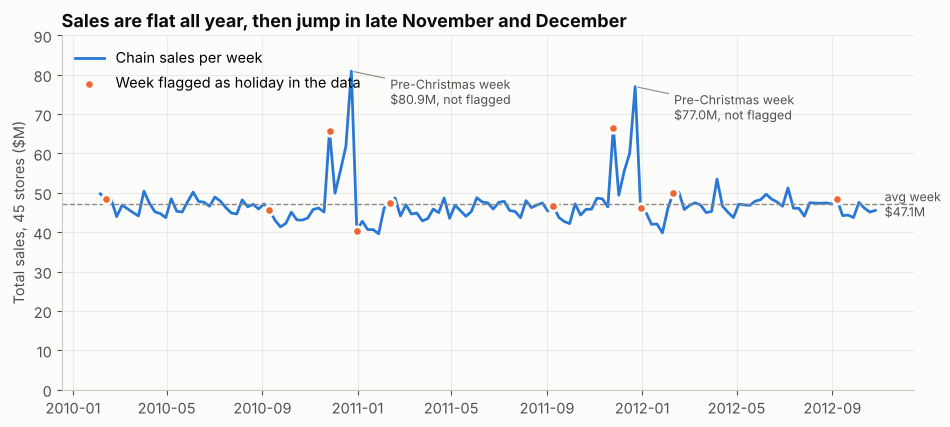

In [4]:
weekly = df.groupby("Date", as_index=False)["Weekly_Sales"].sum()
weekly["Holiday_Flag"] = df.groupby("Date")["Holiday_Flag"].max().values

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(weekly["Date"], weekly["Weekly_Sales"] / 1e6, color=BLUE, lw=2, label="Chain sales per week")
h = weekly[weekly["Holiday_Flag"] == 1]
ax.scatter(h["Date"], h["Weekly_Sales"] / 1e6, s=46, color="#eb6834", edgecolor="#fcfcfb", lw=2, zorder=3,
           label="Week flagged as holiday in the data")
for d in ["2010-12-24", "2011-12-23"]:
    v = weekly.loc[weekly["Date"] == d, "Weekly_Sales"].iat[0] / 1e6
    ax.annotate(f"Pre-Christmas week\n${v:.1f}M, not flagged", (pd.Timestamp(d), v), xytext=(28, -4),
                textcoords="offset points", fontsize=9, color=INK2, va="top",
                arrowprops=dict(arrowstyle="-", color=GREY, lw=0.8))
ax.axhline(weekly["Weekly_Sales"].mean() / 1e6, color=GREY, lw=1, ls="--")
ax.text(weekly["Date"].iloc[-1] + pd.Timedelta(days=12), weekly["Weekly_Sales"].mean() / 1e6, "avg week\n$47.1M",
        ha="left", va="center", fontsize=9, color=INK2)
ax.set_title("Sales are flat all year, then jump in late November and December")
ax.set_ylabel("Total sales, 45 stores ($M)")
ax.set_ylim(0, 90)
ax.legend(loc="upper left", frameon=False)
save(fig, "01_weekly_sales_trend")
plt.show()

In [5]:
# Like-for-like growth: compare the same months (Feb–Oct) because 2010 starts in Feb and 2012 ends in Oct
feb_oct = df[df["Month"].between(2, 10)].groupby("Year")["Weekly_Sales"].sum()
growth = pd.DataFrame({"sales_feb_oct_$bn": feb_oct / 1e9, "yoy_growth_%": feb_oct.pct_change() * 100})
growth

,sales_feb_oct_$bn,yoy_growth_%
Year,,
2010,1.80,NaN
2011,1.79,-0.61
2012,1.83,2.52


The chain is essentially **flat**: like-for-like sales fell 0.6% in 2011 and recovered 2.5% in 2012. The total is
stable, so the useful questions are about *timing* (which weeks) and *mix* (which stores).

## 4. Holiday impact: which holidays actually lift sales?

In [6]:
wk_event = df.groupby(["Date", "Holiday_Event"], as_index=False)["Weekly_Sales"].sum()
base = wk_event.loc[wk_event["Holiday_Event"] == "Regular week", "Weekly_Sales"].mean()
lift = (wk_event.groupby("Holiday_Event")["Weekly_Sales"].agg(["count", "mean"])
        .assign(lift_pct=lambda t: (t["mean"] / base - 1) * 100)
        .rename(columns={"count": "weeks", "mean": "avg_chain_sales"})
        .sort_values("lift_pct"))
lift.assign(avg_chain_sales=lambda t: t["avg_chain_sales"] / 1e6).rename(columns={"avg_chain_sales": "avg_chain_sales_$M"})

,weeks,avg_chain_sales_$M,lift_pct
Holiday_Event,,,
Christmas (flagged week),2,43.24,-6.75
Regular week,131,46.37,0.00
Labor Day,3,46.91,1.17
Super Bowl,3,48.56,4.73
Thanksgiving,2,66.21,42.79
Pre-Christmas (not flagged),2,78.96,70.31


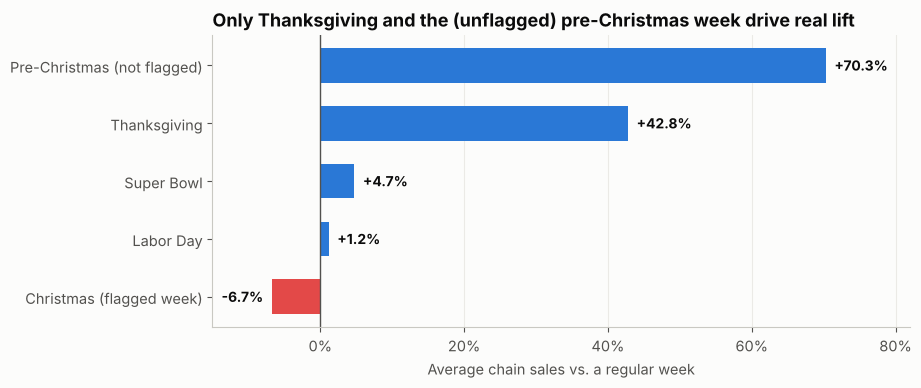

In [7]:
plot = lift.drop("Regular week")
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [RED if v < 0 else BLUE for v in plot["lift_pct"]]
ax.barh(plot.index, plot["lift_pct"], color=colors, height=0.6)
for i, v in enumerate(plot["lift_pct"]):
    ax.text(v + (1.2 if v >= 0 else -1.2), i, f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
            fontsize=10, color=INK, fontweight="bold")
ax.axvline(0, color=INK2, lw=1)
ax.set_xlim(-15, 82)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="y", visible=False)
ax.set_title("Only Thanksgiving and the (unflagged) pre-Christmas week drive real lift")
ax.set_xlabel("Average chain sales vs. a regular week")
save(fig, "02_holiday_lift")
plt.show()

* **Pre-Christmas week: +70%** vs a regular week, and the dataset does *not* flag it as a holiday.
* **Thanksgiving / Black Friday: +43%.**
* **Super Bowl (+5%) and Labor Day (+1%)** are barely distinguishable from a normal week.
* The flagged **"Christmas" week is 7% *below* normal**, because shoppers have already bought.

A simple "Holiday vs Non-Holiday" comparison on the raw flag shows only a +7.8% difference, which hides all of this.

## 5. Seasonality

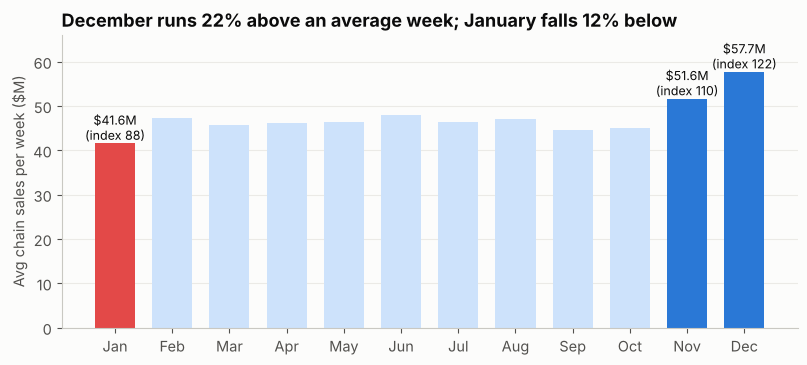

Month,1,2,3,4,5,6,7,8,9,10,11,12
index (avg week = 100),88.00,101.00,97.00,98.00,99.00,102.00,99.00,100.00,94.00,95.00,110.00,122.00


In [8]:
monthly = (weekly.assign(Month=weekly["Date"].dt.month).groupby("Month")["Weekly_Sales"].mean() / 1e6)
idx = monthly / (weekly["Weekly_Sales"].mean() / 1e6) * 100

fig, ax = plt.subplots(figsize=(9.5, 3.8))
names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
cols = [BLUE if m in (11, 12) else (RED if m == 1 else LIGHT) for m in monthly.index]
ax.bar(names, monthly.values, color=cols, width=0.7)
for i, (v, ix) in enumerate(zip(monthly.values, idx.values)):
    if i in (0, 10, 11):
        ax.text(i, v + 0.8, f"${v:.1f}M\n(index {ix:.0f})", ha="center", fontsize=9, color=INK)
ax.set_ylim(0, 66)
ax.set_ylabel("Avg chain sales per week ($M)")
ax.grid(axis="x", visible=False)
ax.set_title("December runs 22% above an average week; January falls 12% below")
save(fig, "03_seasonality_by_month")
plt.show()
idx.round(0).rename("index (avg week = 100)").to_frame().T

## 6. Store performance & momentum

In [9]:
stores = df.groupby("Store")["Weekly_Sales"].agg(total="sum", avg_week="mean")
stores["share_%"] = stores["total"] / stores["total"].sum() * 100
stores["tier"] = pd.qcut(stores["avg_week"].rank(method="first", ascending=False), 4,
                         labels=["1 Large", "2 Upper-mid", "3 Lower-mid", "4 Small"])
ytd = lambda y: df[(df["Year"] == y) & (df["Month"] <= 10)].groupby("Store")["Weekly_Sales"].sum()
stores["ytd_2011"], stores["ytd_2012"] = ytd(2011), ytd(2012)
stores["growth_%"] = (stores["ytd_2012"] / stores["ytd_2011"] - 1) * 100
stores["change_$M"] = (stores["ytd_2012"] - stores["ytd_2011"]) / 1e6

print("Revenue share by size tier (%):")
print(stores.groupby("tier", observed=True)["share_%"].sum().round(1).to_string())
print(f"\nLargest store sells {stores['avg_week'].max() / stores['avg_week'].min():.1f}x the smallest per week")
print(f"Stores growing Jan–Oct 2012 vs 2011: {(stores['growth_%'] > 0).sum()} of 45; declining: {(stores['growth_%'] < 0).sum()}")
stores.sort_values("growth_%")[["avg_week", "tier", "growth_%", "change_$M"]].head(8)

Revenue share by size tier (%):
tier
1 Large       45.10
2 Upper-mid   27.50
3 Lower-mid   17.70
4 Small        9.80

Largest store sells 8.1x the smallest per week
Stores growing Jan–Oct 2012 vs 2011: 37 of 45; declining: 8


,avg_week,tier,growth_%,change_$M
Store,,,,
36,"373,511.99",4 Small,-17.50,-2.82
14,"2,020,978.40",1 Large,-8.56,-7.25
21,"756,069.08",3 Lower-mid,-5.01,-1.59
27,"1,775,216.20",1 Large,-2.62,-1.94
15,"623,312.47",3 Lower-mid,-1.73,-0.44
28,"1,323,522.24",2 Upper-mid,-0.60,-0.33
19,"1,444,999.04",1 Large,-0.55,-0.32
31,"1,395,901.44",1 Large,-0.16,-0.10


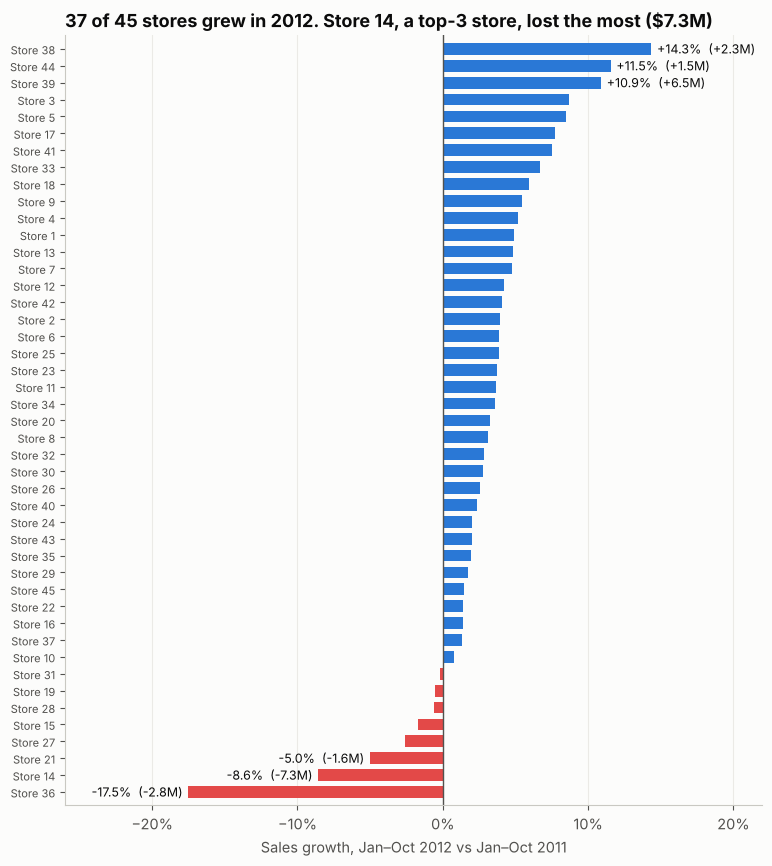

In [10]:
s = stores.sort_values("growth_%")
fig, ax = plt.subplots(figsize=(9, 10))
ax.barh([f"Store {i}" for i in s.index], s["growth_%"], color=[RED if v < 0 else BLUE for v in s["growth_%"]], height=0.7)
ax.axvline(0, color=INK2, lw=1)
for name in [36, 14, 21, 38, 44, 39]:
    pos = list(s.index).index(name); v = s.loc[name, "growth_%"]
    ax.text(v + (0.4 if v > 0 else -0.4), pos, f"{v:+.1f}%  ({s.loc[name, 'change_$M']:+.1f}M)",
            va="center", ha="left" if v > 0 else "right", fontsize=9, color=INK)
ax.set_xlim(-26, 22)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.tick_params(axis="y", labelsize=8)
ax.grid(axis="y", visible=False)
ax.margins(y=0.01)
ax.set_title("37 of 45 stores grew in 2012. Store 14, a top-3 store, lost the most ($7.3M)")
ax.set_xlabel("Sales growth, Jan–Oct 2012 vs Jan–Oct 2011")
save(fig, "04_store_growth")
plt.show()

* Revenue is concentrated: the **12 largest stores generate 45% of sales**; the 11 smallest generate under 10%.
  The biggest store sells about 8x the smallest per week.
* **37 of 45 stores grew** in 2012. Of the 8 decliners, **Store 14** matters most. It is the #3 store by revenue and
  lost **$7.3M (-8.6%)**, about half of everything the 8 declining stores lost. **Store 36** fell the fastest (-17.5%).
* **Stores 38, 44 and 39** grew 11–14% and are worth studying for practices that could be copied.

## 7. Store-level holiday sensitivity

Median multiplier: 1.68x | range 0.97x to 2.05x
Stores with almost no Christmas peak (<1.3x): [33, 36, 42, 38, 43, 37, 30, 44]


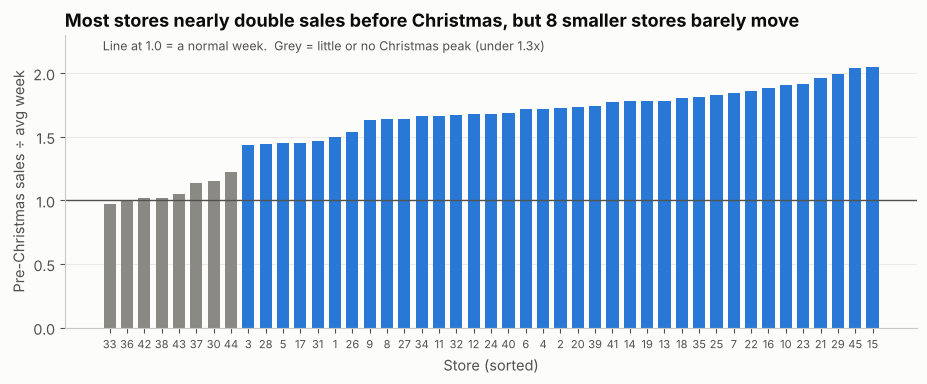

In [11]:
pre = df[df["Holiday_Event"] == "Pre-Christmas (not flagged)"].groupby("Store")["Weekly_Sales"].mean()
stores["xmas_multiplier"] = pre / stores["avg_week"]
m = stores["xmas_multiplier"].sort_values()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar([str(i) for i in m.index], m.values, color=[GREY if v < 1.3 else BLUE for v in m.values], width=0.7)
ax.axhline(1, color=INK2, lw=1)
ax.text(-0.4, 2.18, "Line at 1.0 = a normal week.  Grey = little or no Christmas peak (under 1.3x)", fontsize=9, color=INK2)
ax.set_ylim(0, 2.3)
ax.set_xlabel("Store (sorted)")
ax.set_ylabel("Pre-Christmas sales ÷ avg week")
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", labelsize=8)
ax.set_title("Most stores nearly double sales before Christmas, but 8 smaller stores barely move")
save(fig, "05_christmas_peak_by_store")
plt.show()
print(f"Median multiplier: {m.median():.2f}x | range {m.min():.2f}x to {m.max():.2f}x")
print("Stores with almost no Christmas peak (<1.3x):", list(m[m < 1.3].index))

The median store sells **1.7x** a normal week in the pre-Christmas week, and Stores 15, 45 and 29 sell over 2x.
But eight smaller stores (33, 36, 42, 38, 43, 37, 30, 44) show almost **no Christmas peak**.
A single chain-wide holiday inventory and staffing plan over-stocks those eight stores and under-stocks the peak stores.

## 8. External factors: do they matter?

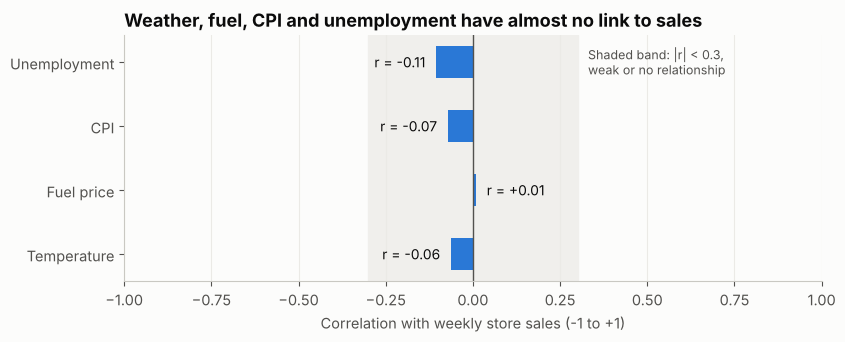

,all stores (pooled),median within-store
Temperature,-0.06,-0.13
Fuel price,0.01,-0.00
CPI,-0.07,0.08
Unemployment,-0.11,-0.05


In [12]:
factors = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
corr = pd.DataFrame({
    "all stores (pooled)": [df["Weekly_Sales"].corr(df[f]) for f in factors],
    "median within-store": [df.groupby("Store").apply(lambda g: g["Weekly_Sales"].corr(g[f])).median() for f in factors],
}, index=["Temperature", "Fuel price", "CPI", "Unemployment"])

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(corr.index, corr["all stores (pooled)"], color=BLUE, height=0.5)
for i, v in enumerate(corr["all stores (pooled)"]):
    ax.text(v + (0.03 if v >= 0 else -0.03), i, f"r = {v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=10, color=INK)
ax.axvline(0, color=INK2, lw=1)
ax.axvspan(-0.3, 0.3, color="#f0efec", zorder=0)
ax.text(0.33, 3, "Shaded band: |r| < 0.3,\nweak or no relationship", fontsize=9, color=INK2, va="center")
ax.set_xlim(-1, 1)
ax.grid(axis="y", visible=False)
ax.set_title("Weather, fuel, CPI and unemployment have almost no link to sales")
ax.set_xlabel("Correlation with weekly store sales (-1 to +1)")
save(fig, "06_external_factors")
plt.show()
corr.round(3)

Across all stores, every external factor has a correlation between **-0.11 and +0.01** with weekly sales. Looking
within each store over time (median per store) gives the same answer: no factor is stronger than ±0.13. Over this period, sales are explained by **which store** it is and **which week of
the year** it is, not by the macro-economy. Note that CPI in this data mainly tells you the store's region,
so any apparent "CPI effect" is really a store-mix effect.

## Export: clean dataset for the Tableau dashboard

In [13]:
out = df.merge(stores[["tier", "growth_%", "xmas_multiplier"]].rename(columns={
          "tier": "Size_Tier", "growth_%": "Store_Growth_2012_pct", "xmas_multiplier": "Store_Xmas_Multiplier"}),
      left_on="Store", right_index=True)
out["Date"] = out["Date"].dt.strftime("%Y-%m-%d")
out.to_csv("data/walmart_clean.csv", index=False)
print(out.shape); out.head(3)

(6435, 14)


## 9. Key findings & recommendations

| # | Finding | Recommendation |
|---|---|---|
| 1 | The pre-Christmas week is the biggest week of the year (+70%, about $79M), but the data does **not** flag it as a holiday. The flagged "Christmas" week is 7% *below* normal. | Correct the holiday calendar used in reporting and forecasting. Treat the 2 weeks before Christmas as the peak period. |
| 2 | Only Thanksgiving (+43%) and pre-Christmas (+70%) produce real lift. Super Bowl (+5%) and Labor Day (+1%) are close to a normal week. | Put peak staffing, inventory and promotion budget into late Nov–Dec. Run Super Bowl / Labor Day as normal weeks. |
| 3 | December runs 22% above average; January falls 12% below, the weakest month. | Plan January clearance and lower-cost staffing schedules; use January for training and resets. |
| 4 | 12 large stores = 45% of revenue. Store 14 (#3 by revenue) lost $7.3M (-8.6%) in 2012; Store 36 fell 17.5%. | Prioritise a performance review of Store 14 (local competition, staffing, out-of-stocks). Study Stores 38, 44 and 39 (+11–14%) for practices to copy. |
| 5 | Christmas sensitivity varies 1.0x–2.05x by store; 8 small stores have no holiday peak. | Replace the one-size holiday plan with store-level allocation based on each store's own peak multiplier. |
| 6 | Temperature, fuel price, CPI and unemployment show almost no correlation with sales (\|r\| ≤ 0.13). | Base forecasts on store history and calendar effects. Don't spend modelling effort on these macro inputs. |

**Limitations:** the data covers only 2.75 years and 45 stores, has no department, product, margin or traffic data,
and correlation does not prove causation. The next step would be adding store size/type and department-level data
to explain *why* Store 14 is declining.